#Classificação para Perfil Propenso a Perdas

Este notebook usa Random Forest para classificar se um usuário é propenso a perder isqueiros.
- Usa dados reais do LighterTracker.
- 4 variáveis X (input) e 1 variável Y (output).
- Objetivo: Demonstrar funcionalidade do protótipo para segmentar usuários e personalizar alertas.

## 1. Configuração Inicial


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
# Configurações para visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette('deep')

In [5]:
# Definir semente para reprodutibilidade
np.random.seed(42)

In [6]:
# Carregar tabelas
data_dir = '/content/'
dfs = {
    'usuarios': pd.read_csv(data_dir + 'usuarios.csv'),
    'utilizacao': pd.read_csv(data_dir + 'utilizacao.csv'),
    'locais': pd.read_csv(data_dir + 'locais.csv'),
    'historico_localizacao': pd.read_csv(data_dir + 'historico_localizacao.csv'),
    'isqueiros_usuario': pd.read_csv(data_dir + 'isqueiros_usuario.csv')
}

In [7]:
# Converter colunas de data
dfs['usuarios']['DataNascimento'] = pd.to_datetime(dfs['usuarios']['DataNascimento'])
dfs['utilizacao']['DataHoraUso'] = pd.to_datetime(dfs['utilizacao']['DataHoraUso'])
dfs['historico_localizacao']['DataHoraRegistro'] = pd.to_datetime(dfs['historico_localizacao']['DataHoraRegistro'])

## 2. Preparação dos Dados

- X (variáveis explicativas):
- idade: Calculada a partir de DataNascimento (usuarios).
- uso_em_bares: Proporção de usos em bares (utilizacao e locais).
- frequencia_uso: Número total de usos por usuário (utilizacao).
- n_isqueiros: Número de isqueiros comprados (isqueiros_usuario).
- Y (variável alvo): perfil_perda (1 = propenso a perder, 0 = não propenso, baseado em >=2 perdas).

In [8]:
# Calcular número de perdas por usuário
perdas = dfs['historico_localizacao'][dfs['historico_localizacao']['TipoEvento'] == 'Perdido']
perdas = perdas.merge(dfs['isqueiros_usuario'][['IsqueiroUsuarioID', 'UsuarioID']], on='IsqueiroUsuarioID')
perdas_por_usuario = perdas.groupby('UsuarioID').size().reset_index(name='n_perdas')
perdas_por_usuario['perfil_perda'] = (perdas_por_usuario['n_perdas'] >= 2).astype(int)

In [9]:

# Calcular frequência de uso por usuário
frequencia_uso = dfs['utilizacao'].merge(
    dfs['isqueiros_usuario'][['IsqueiroUsuarioID', 'UsuarioID']], on='IsqueiroUsuarioID'
).groupby('UsuarioID').size().reset_index(name='frequencia_uso')

In [10]:
# Calcular proporção de uso em bares
uso_em_bares = dfs['utilizacao'].merge(dfs['locais'][['LocalID', 'TipoLocal']], on='LocalID')
uso_em_bares = uso_em_bares[uso_em_bares['TipoLocal'] == 'Bar'].merge(
    dfs['isqueiros_usuario'][['IsqueiroUsuarioID', 'UsuarioID']], on='IsqueiroUsuarioID'
).groupby('UsuarioID').size().reset_index(name='usos_bares')
total_usos = dfs['utilizacao'].merge(
    dfs['isqueiros_usuario'][['IsqueiroUsuarioID', 'UsuarioID']], on='IsqueiroUsuarioID'
).groupby('UsuarioID').size().reset_index(name='total_usos')
uso_em_bares = uso_em_bares.merge(total_usos, on='UsuarioID', how='left').fillna({'total_usos': 1})
uso_em_bares['uso_em_bares'] = uso_em_bares['usos_bares'] / uso_em_bares['total_usos']

In [11]:
uso_em_bares.head()

,UsuarioID,usos_bares,total_usos,uso_em_bares
0,1,3,14,0.214286
1,3,2,3,0.666667
2,5,1,17,0.058824
3,6,2,9,0.222222
4,8,5,14,0.357143


In [12]:
# Calcular número de isqueiros por usuário
n_isqueiros = dfs['isqueiros_usuario'].groupby('UsuarioID').size().reset_index(name='n_isqueiros')

In [13]:
# Criar base de dados
dados_classificacao = dfs['usuarios'][['UsuarioID', 'DataNascimento']].copy()
dados_classificacao['idade'] = (pd.to_datetime('2025-07-30') - dados_classificacao['DataNascimento']).dt.days // 365
dados_classificacao = dados_classificacao.merge(frequencia_uso, on='UsuarioID', how='left').fillna({'frequencia_uso': 0})
dados_classificacao = dados_classificacao.merge(uso_em_bares[['UsuarioID', 'uso_em_bares']], on='UsuarioID', how='left').fillna({'uso_em_bares': 0})
dados_classificacao = dados_classificacao.merge(n_isqueiros, on='UsuarioID', how='left').fillna({'n_isqueiros': 0})
dados_classificacao = dados_classificacao.merge(perdas_por_usuario[['UsuarioID', 'perfil_perda']], on='UsuarioID', how='left').fillna({'perfil_perda': 0})
dados_classificacao = dados_classificacao[['idade', 'uso_em_bares', 'frequencia_uso', 'n_isqueiros', 'perfil_perda']]

In [14]:

# Visualizar
print("\n### Base de Dados")
display(dados_classificacao.head())


### Base de Dados


,idade,uso_em_bares,frequencia_uso,n_isqueiros,perfil_perda
0,23,0.214286,14.0,7.0,0.0
1,71,0.000000,5.0,5.0,0.0
2,74,0.666667,3.0,2.0,0.0
3,64,0.000000,6.0,7.0,0.0
4,35,0.058824,17.0,9.0,0.0


## 3. Separar X e Y

In [19]:
# Objetivo: Definir variáveis explicativas (X) e alvo (Y).
X = dados_classificacao[['idade', 'uso_em_bares', 'frequencia_uso', 'n_isqueiros']]
y = dados_classificacao['perfil_perda']

## 4. Dividir em Treino e Teste

In [18]:

# Objetivo: Separar 80% dos dados para treino e 20% para teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Treinamento do Modelo

In [17]:

# Objetivo: Treinar um Random Forest para classificar o perfil do usuário.
model_clf = RandomForestClassifier(n_estimators=100, random_state=42)
model_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 6. Avaliação do Modelo

In [20]:

# Objetivo: Avaliar o desempenho com acurácia e matriz de confusão.
y_pred = model_clf.predict(X_test)

In [21]:
# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n### Avaliação")
print(f"Acurácia: {accuracy:.3f}")
print("\nMatriz de Confusão:")
print(cm)




### Avaliação
Acurácia: 0.824

Matriz de Confusão:
[[1632   92]
 [ 261   15]]


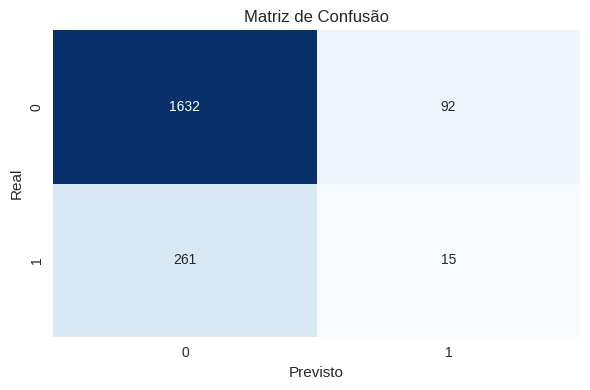

In [23]:
# Visualizar matriz de confusão
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Previsto')  # Added x-label
plt.ylabel('Real')      # Added y-label
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.show()